# Geometry Mismatch: PGD vs Mirror Descent

We solve:

    minimize    f(x) = Σ x_i log(x_i / c_i)
    subject to  x ≥ 0,  Σ x_i = 1

This is KL divergence:  KL(x || c)

True minimizer:  x = c

We compare:

1) Projected Gradient Descent (Euclidean)
2) Entropy Mirror Descent

Hypothesis:
PGD struggles due to geometry mismatch.
Mirror converges smoothly because KL matches entropy geometry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

In [2]:
def kl_objective(x, c, eps=1e-12):
    x_safe = np.clip(x, eps, 1)
    return np.sum(x_safe * np.log(x_safe / c))

def kl_gradient(x, c):
    return np.log(x / c) + 1

In [3]:
def project_simplex(v):
    v = np.asarray(v)
    n = v.shape[0]
    
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    
    rho_candidates = np.where(u * np.arange(1, n+1) > (cssv - 1))[0]
    
    if len(rho_candidates) == 0:
        return np.ones(n) / n
    
    rho = rho_candidates[-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    
    return np.maximum(v - theta, 0)

In [4]:
def pgd_step(x, c, eta):
    g = kl_gradient(x, c)
    x_new = x - eta * g
    return project_simplex(x_new)

In [5]:
def mirror_entropy_step(x, c, eta):
    g = kl_gradient(x, c)
    x_new = x * np.exp(-eta * g)
    x_new = x_new / np.sum(x_new)
    return x_new

In [6]:
c = np.array([1e-4, 1 - 1e-4])
x0 = np.array([0.5, 0.5])

eta_pgd = 0.05
eta_mirror = 0.5   # larger stable step

steps = 200

In [7]:
def run(method, x0, c, eta, steps, eps=1e-12):
    x = x0.copy()
    traj = [x.copy()]
    losses = []
    
    for _ in range(steps):
        x = np.clip(x, eps, 1.0)
        x = x / np.sum(x)
        
        losses.append(kl_objective(x, c))
        
        x = method(x, c, eta)
        traj.append(x.copy())
    
    return np.array(traj), np.array(losses)

pgd_traj, pgd_loss = run(pgd_step, x0, c, eta_pgd, steps)
mirror_traj, mirror_loss = run(mirror_entropy_step, x0, c, eta_mirror, steps)

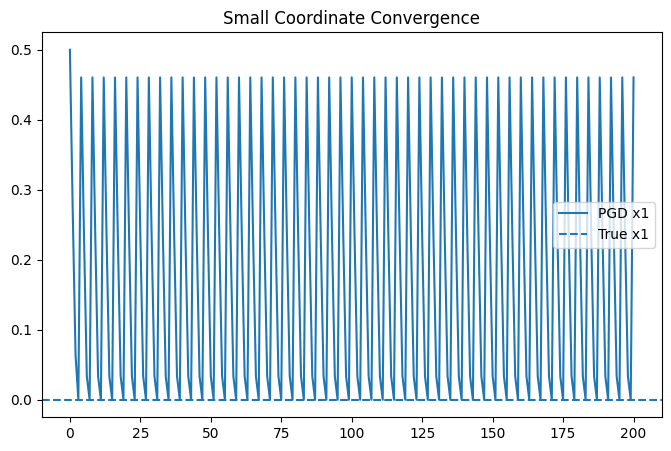

In [8]:
plt.figure(figsize=(8,5))
plt.plot(pgd_traj[:,0], label="PGD x1")
plt.axhline(c[0], linestyle="--", label="True x1")
plt.legend()
plt.title("Small Coordinate Convergence")
plt.show()

PGD : 

overshoot → projection → overshoot → projection

PGD does not respect simplex geometry.

It is numerically unstable for this η.



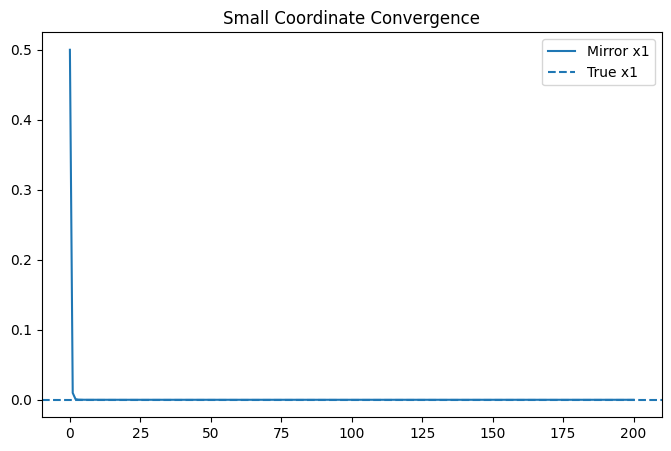

In [9]:
plt.figure(figsize=(8,5))
plt.plot(mirror_traj[:,0], label="Mirror x1")

plt.axhline(c[0], linestyle="--", label="True x1")
plt.legend()
plt.title("Small Coordinate Convergence")
plt.show()

Mirror GD :


Multiplicative update naturally shrinks small coordinate

No projection needed

Stable even with larger η

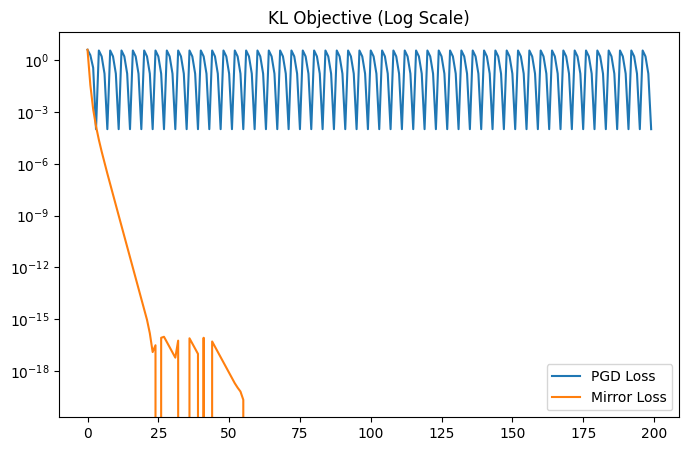

In [10]:
plt.figure(figsize=(8,5))
plt.plot(pgd_loss, label="PGD Loss")
plt.plot(mirror_loss, label="Mirror Loss")
plt.yscale("log")
plt.legend()
plt.title("KL Objective (Log Scale)")
plt.show()

So this plot is telling :

PGD fails to make consistent descent steps.

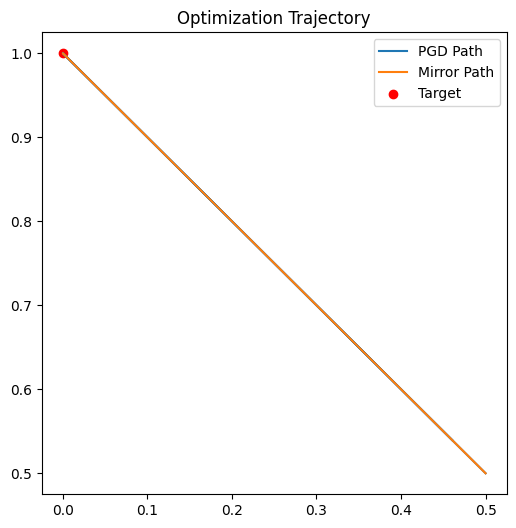

In [11]:
plt.figure(figsize=(6,6))
plt.plot(pgd_traj[:,0], pgd_traj[:,1], label="PGD Path")
plt.plot(mirror_traj[:,0], mirror_traj[:,1], label="Mirror Path")
plt.scatter(c[0], c[1], color='red', label="Target")
plt.legend()
plt.title("Optimization Trajectory")
plt.show()